# Análisis exploratorio - Dataset Student Performance (Desempeño de estudiantes)

***Materia:*** Métodos de Análisis de Datos 1
***Alumno:*** Godoy Martin

---

## Objetivo

Carga y exploracion inicial de un dataset en el formato de CSV

---

## Paso 1: Carga de Datos

In [129]:
#Importamos librerias necesarias
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
warnings.filterwarnings('ignore')

#Configuramos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)


print('Librerias importadas correctamente')

Librerias importadas correctamente


### Exploracion inicial

Vemos las primeras filas de nuestro Dataset

In [130]:
#Leemos primeras lineas
df = pd.read_csv('SP.csv')
df.head(20)

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes
5,STU0006,Female,19,8,85.2,High School,Yes,No,40,37,No
6,STU0007,Male,18,10,72.7,Master,Yes,No,75,42,No
7,STU0008,Female,15,21,81.7,NaN,Yes,Yes,89,70,Yes
8,STU0009,Female,19,9,84.2,High School,Yes,Yes,70,49,No
9,STU0010,Female,15,8,95.7,NaN,No,Yes,93,56,Yes


In [131]:
#Info general
print("Informacion del Dataset:\n")
df.info()

Informacion del Dataset:

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


In [132]:
#Estadisticas descriptivas
print(f"Informacion general del Datasheet:\n")
df.describe()

Informacion general del Datasheet:



,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


Se aprecian algunas estadísticas como la media, mínimo, máximo cuartiles y desviacion estándar

---

## Paso 2: Calidad de los Datos

### 2.1 Valores faltantes

In [133]:
#Detectamos los valores faltantes

print('Valores faltantes por columna:\n')
df.isnull().sum()

Valores faltantes por columna:



student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

A pesar de haber valores faltantes, estos estan en parent_education, pero dado el contexto tiene sentido en este caso que los haya, pues implicaria que los padres no han tenido algun tipo de educacion.

### 2.2 Duplicados

In [134]:
#Eliminamos los duplicados

print(f"Dataset previo a la eliminacion: {df.shape[0]} filas")
df = df.drop_duplicates()
print(f"\nDataset posterior a la eliminacion: {df.shape[0]} filas")

Dataset previo a la eliminacion: 500 filas

Dataset posterior a la eliminacion: 500 filas


No hay valores duplicados

### 2.3 Inconsistencias

In [135]:
#Deteccion de valores anormales:

#Genero fuera de Male/Female (teniendo el dataset como se tiene, se lo considerara como error)
genero_indefinido = df[(df['gender'].str.strip().str.lower() != 'male') & (df['gender'].str.strip().str.lower() != 'female')]

#Edades fuera de rango
edad_fuera_rango = df[(df['age'] < 14) | (df['age'] > 20)]

#Horas de estudio semanal fuera de rango
horas_fuera_rango = df[(df['study_hours_per_week'] < 2) | (df['study_hours_per_week'] > 30)]

#Porcentaje de presencia
presencia_fuera_rango = df[(df['attendance_rate'] < 0) | (df['attendance_rate'] > 100)]

#Puntaje (anterior/final) fuera de rango
puntaje_fuera_rango = df[(df['previous_score'] < 0) | (df['final_score'] < 0) | (df['previous_score'] > 100) | (df['final_score'] > 100)]

#Educacion de padres como 'NaN'
educacion_padres = df[df['parent_education'].isna()] 

print("Genero indefinido:", len(genero_indefinido))
print("\nEdades fuera de rango:", len(edad_fuera_rango))
print("\nHoras de estudio semanales fuera de rango:", len(horas_fuera_rango))
print("\nPorcentaje de presencia fuera de rango:", len(presencia_fuera_rango))
print("\nPuntaje fuera de rango:", len(puntaje_fuera_rango))
print("\nEducacion de padres como NaN:", len(educacion_padres))

Genero indefinido: 0

Edades fuera de rango: 0

Horas de estudio semanales fuera de rango: 0

Porcentaje de presencia fuera de rango: 0

Puntaje fuera de rango: 0

Educacion de padres como NaN: 117


Se verifican posibles inconsistencias de datos:
- Generos indefinidos
- Edades que no tienen sentido para estudiantes de secundaria
- Horas de estudios semanales por fuera del rango
- Porcentajes de presencia sin sentido (menores al 0% o mayores al 100%)
- Puntajes sin sentido (puntajes negativos o mayores que el 100)

In [136]:
df_clean = df.copy()

#Deteccion de valores invalidos

#Generos indefinidos (reemplazamos con desconocido)
df_clean.loc[
    (df_clean['gender'].str.strip().str.lower() != 'male') & (df_clean['gender'].str.strip().str.lower() != 'female'), 
    'gender'
    ] = 'Desconocido'

#Edades fuera de rango
df_clean.loc[
    (df_clean['age'] < 14) | (df_clean['age'] > 20),
    'age' 
    ] = np.nan

#Horas de estudio fuera del rango
df_clean.loc[
    (df_clean['study_hours_per_week'] < 2 ) | (df_clean['study_hours_per_week'] > 30),
    'study_hours_per_week'
    ]  = np.nan

#Porcentajes de presencia fuera de rango
df_clean.loc[
    (df_clean['attendance_rate'] < 0) | (df_clean['attendance_rate'] > 100),
    'attendance_rate'
    ]  = np.nan

#Puntajes fuera del rango 
df_clean.loc[
    (df_clean['previous_score'] < 0) | (df_clean['final_score'] < 0) | (df_clean['previous_score'] > 100) | (df_clean['final_score'] > 100),
    ['previous_score', 'final_score']
    ]  = np.nan

#Niveles educativos de los padres (Reemplazamos los NaN con 'None')
df_clean.loc[
    (df_clean['parent_education'].isnull()),
    'parent_education'
    ] = 'None'

#Imputar valores faltantes

#Para edades utilizaremos mediana, que es mas robusta
df_clean['age'].fillna(df_clean['age'].median(), inplace= True)

#Para horas de estudio semanales, presencialidad, puntaje previo y final, usaremos la media
df_clean['study_hours_per_week'].fillna(df_clean['study_hours_per_week'].mean(), inplace= True)
df_clean['attendance_rate'].fillna(df_clean['attendance_rate'].mean(), inplace= True)
df_clean['previous_score'].fillna(df_clean['previous_score'].mean(), inplace= True)
df_clean['final_score'].fillna(df_clean['final_score'].mean(), inplace= True)


print("Verificando despues de corregir")

print("Edades fuera de rango:",((df_clean['age'] < 14) | (df_clean['age'] > 20)).sum())
print("Horas de estudio fuera del rango:", ((df_clean['study_hours_per_week'] < 2 ) | (df_clean['study_hours_per_week'] > 30)).sum())
print("Porsentajes de asistencia fuera de rango:", ((df_clean['attendance_rate'] < 0) | (df_clean['attendance_rate'] > 100)).sum())
print("Puntajes fuera de rango:", ((df_clean['previous_score'] < 0) | (df_clean['final_score'] < 0) | (df_clean['previous_score'] > 100) | (df_clean['final_score'] > 100)).sum())
print("Generos indefinidos:", (df_clean['gender'] == 'Desconocido').sum())
print("Niveles educativos de padres corregidos:", (df_clean['parent_education'] == 'None').sum())

df = df_clean


Verificando despues de corregir
Edades fuera de rango: 0
Horas de estudio fuera del rango: 0
Porsentajes de asistencia fuera de rango: 0
Puntajes fuera de rango: 0
Generos indefinidos: 0
Niveles educativos de padres corregidos: 117


En primera instancia se identifican los valores fuera de rango en el dataset. Estos fueron reemplazados por valores nulos (NaN) e imputados:
- Para las edades se utilizo la mediana
- Para horas de estudio, asistencia, puntajes previo y finales se utilizo la media
- Para generos indefinidos se los reemplazo por 'Desconocido'

Esto se hizo para mantener consistencia, pues que haya falta de datos modifica el analisis, cosa que no es de interes.

---

## Paso 3: Transformación de Datos

### 3.1 Verificar y convertir tipos

In [137]:
#Verificamos los tipos de datos actuales
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
student_id                  str
gender                      str
age                     float64
study_hours_per_week    float64
attendance_rate         float64
parent_education            str
internet_access             str
extracurricular             str
previous_score          float64
final_score             float64
passed                      str
dtype: object


In [138]:
#Convertimos tipos
df['parent_education'] = pd.Categorical(
    df['parent_education'],
    categories=['None', 'High School', 'Bachelor', 'Master', 'PhD'],
    ordered= True
) 

print("Tipos de datos luego de convertir:")
print(df.dtypes)

Tipos de datos luego de convertir:
student_id                   str
gender                       str
age                      float64
study_hours_per_week     float64
attendance_rate          float64
parent_education        category
internet_access              str
extracurricular              str
previous_score           float64
final_score              float64
passed                       str
dtype: object


Se cambio el tipo de dato de 'parent_education' a 'category', con el proposito de categorizar los distintos niveles educativos de los padres.

### 3.2 Creacion de variables derivadas

In [139]:
#Creamos la variable mejora de rendimiento, vale True si este mejoro
df['mejora_puntaje'] = (df['final_score'] > df['previous_score'])

#Creamos la variable ratio de puntaje por hora, mide la eficiencia de un alumno
df['puntaje_por_hora'] = (df['final_score'] / df['study_hours_per_week'])    

#Creamos la variable compromiso, mide que tanto se esforzo un alumno 
df['comrpomiso'] = (df['study_hours_per_week']*0.65 + df['attendance_rate']*0.35)   #El peso que tiene cada una esta puesta a criterio

print('Variables creadas:')
df[['mejora_puntaje', 'puntaje_por_hora', 'comrpomiso']].head(10)

Variables creadas:


,mejora_puntaje,puntaje_por_hora,comrpomiso
0,True,2.680000,38.580
1,False,14.000000,20.445
2,False,4.900000,38.175
3,False,2.692308,40.280
4,True,3.080000,41.800
5,False,4.625000,35.020
6,False,4.200000,31.945
7,False,3.333333,42.245
8,False,5.444444,35.320
9,False,7.000000,38.695


Se crearon las variables 'mejora de puntaje', 'puntaje por hora' y 'compromiso' que puede resultar util para ver el rendimiento que tienen los estudiantes, como afectan las horas de estudio semanales al puntaje final y que tan comprometidos estan con su estudio

---

## Paso 4: Normalización y Estandarización

In [140]:
#Antes de escalar guardamos una copia
df_pre_scaling = df.copy()

#Seleccionamos columnas numericas a escalar
numeric_cols = ['age', 'study_hours_per_week', 'attendance_rate', 'previous_score','final_score']

### 4.1 Min-Max Scaling

In [141]:
from sklearn.preprocessing import MinMaxScaler

#Aplicamos Min-Max
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

#Comparamos
print("Previo a Min_Max:")
print(df[numeric_cols].describe())

print("\nPosterior a Min-Max:")
print(df_minmax[numeric_cols].describe())

Previo a Min_Max:
              age  study_hours_per_week  attendance_rate  previous_score  \
count  500.000000            500.000000       500.000000      500.000000   
mean    16.978000             15.312000        76.380600       62.986000   
std      1.434445              8.568167        13.817681       18.937451   
min     15.000000              2.000000        50.200000       30.000000   
25%     16.000000              8.000000        64.475000       46.000000   
50%     17.000000             15.000000        76.500000       64.000000   
75%     18.000000             23.000000        88.525000       79.000000   
max     19.000000             30.000000       100.000000       95.000000   

       final_score  
count   500.000000  
mean     55.980000  
std      15.373754  
min      20.000000  
25%      45.000000  
50%      56.000000  
75%      68.000000  
max      95.000000  

Posterior a Min-Max:
              age  study_hours_per_week  attendance_rate  previous_score  \
count  500

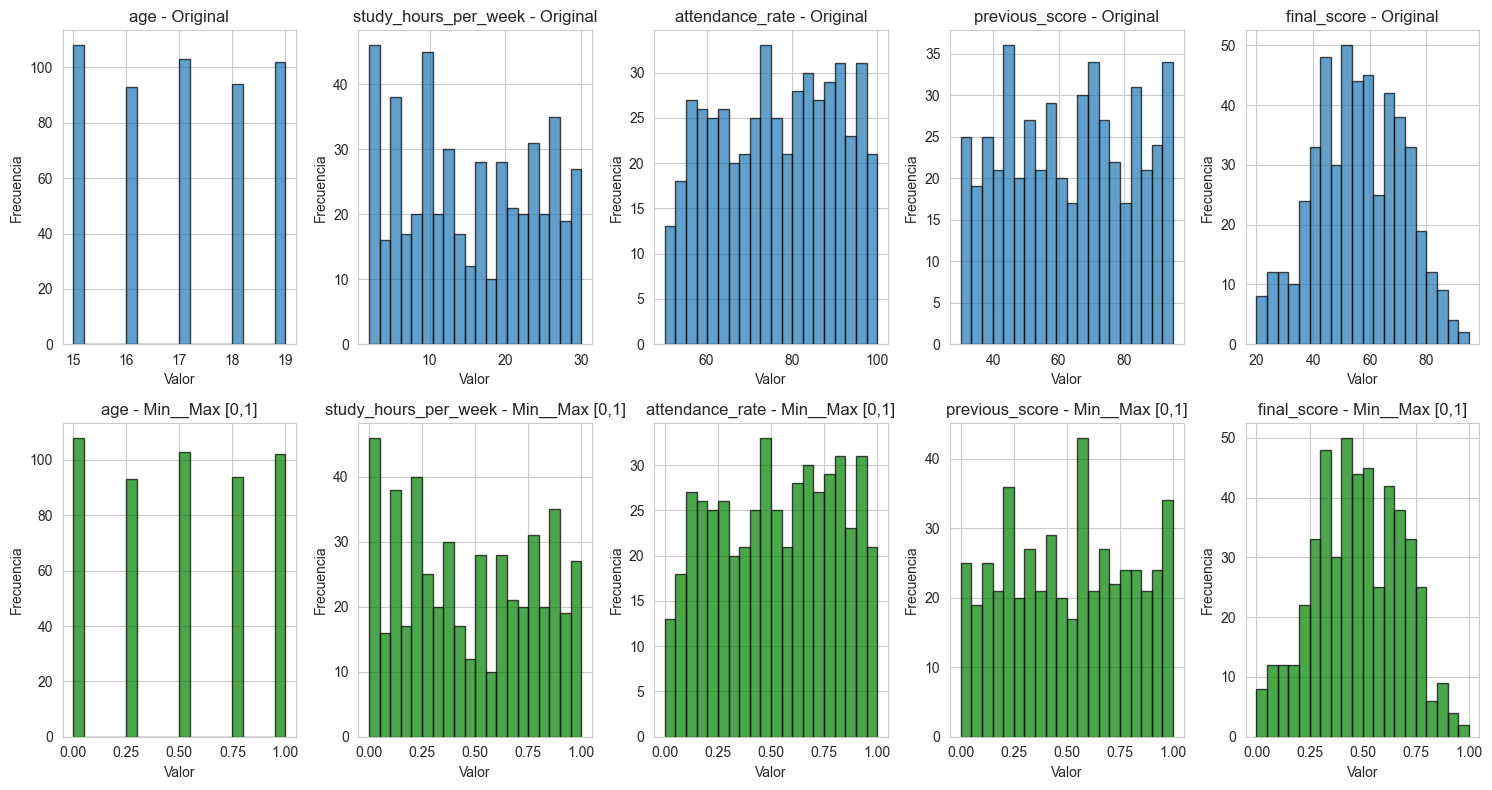

In [142]:
#Vemos las distribuciones antes y despues
fig, axes = plt.subplots(2, 5, figsize=(15,8))

for i, col in enumerate(numeric_cols):
    #Original
    axes[0,i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[0,i].set_title(f'{col} - Original')
    axes[0,i].set_xlabel('Valor')
    axes[0,i].set_ylabel('Frecuencia')

    #Normalizado
    axes[1,i].hist(df_minmax[col], bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1,i].set_title(f'{col} - Min__Max [0,1]')
    axes[1,i].set_xlabel('Valor')
    axes[1,i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


### 4.2 Standarizatioin (Z-score)

In [143]:
from sklearn.preprocessing import StandardScaler

#Aplicar standarization
scaler_std = StandardScaler()
df_std = df.copy()
df_std[numeric_cols] = scaler_std.fit_transform(df[numeric_cols])

#Comparar
print("Antes de la Standarization:")
print(df[numeric_cols].describe())
print("\nDespues de Standarization:")
print(df_std[numeric_cols].describe())

Antes de la Standarization:
              age  study_hours_per_week  attendance_rate  previous_score  \
count  500.000000            500.000000       500.000000      500.000000   
mean    16.978000             15.312000        76.380600       62.986000   
std      1.434445              8.568167        13.817681       18.937451   
min     15.000000              2.000000        50.200000       30.000000   
25%     16.000000              8.000000        64.475000       46.000000   
50%     17.000000             15.000000        76.500000       64.000000   
75%     18.000000             23.000000        88.525000       79.000000   
max     19.000000             30.000000       100.000000       95.000000   

       final_score  
count   500.000000  
mean     55.980000  
std      15.373754  
min      20.000000  
25%      45.000000  
50%      56.000000  
75%      68.000000  
max      95.000000  

Despues de Standarization:
                age  study_hours_per_week  attendance_rate  previous_s

---

## Paso 5: Discretización (binning)

En este caso las variables elegidas para hacer Discretización son 'horas de estudio semanales', 'puntaje previo' y 'edad'

In [144]:
#Bins de igual ancho
df['puntajeprev_bins_ancho'] = pd.cut(
    df['previous_score'],
    bins = 5,
    labels = ['F','D','C','B','A']
)

print("Bins de igual ancho (Puntaje previo):")
print(df['puntajeprev_bins_ancho'].value_counts().sort_index())

Bins de igual ancho (Puntaje previo):
puntajeprev_bins_ancho
F    101
D    104
C     98
B     94
A    103
Name: count, dtype: int64


In [145]:
#Bins con puntos especificos
df['horasestudio_bins_custom'] = pd.cut(
    df['study_hours_per_week'],
    bins= [0, 2, 7, 12, 20, 30],
    labels = ['Muy pocas', 'Pocas', 'Promedio', 'Muchas', 'Demasiadas']
)

print("Bins custom (Horas de estudio semanales):")
print(df['horasestudio_bins_custom'].value_counts().sort_index())

Bins custom (Horas de estudio semanales):
horasestudio_bins_custom
Muy pocas      22
Pocas          95
Promedio      102
Muchas        108
Demasiadas    173
Name: count, dtype: int64


In [146]:
#Bins de igual frecuencia (cuartiles)
df['edad_cuartiles'] = pd.qcut(
    df['age'],
    q=4,
    labels = ['Q1','Q2','Q3','Q4']
)

print("Cuartiles (Edades):")
print(df['edad_cuartiles'].value_counts().sort_index())
print("\nNota: Cada cuartil tiene aprox la misma cantidad de observaciones")

Cuartiles (Edades):
edad_cuartiles
Q1    201
Q2    103
Q3     94
Q4    102
Name: count, dtype: int64

Nota: Cada cuartil tiene aprox la misma cantidad de observaciones


<function matplotlib.pyplot.show(close=None, block=None)>

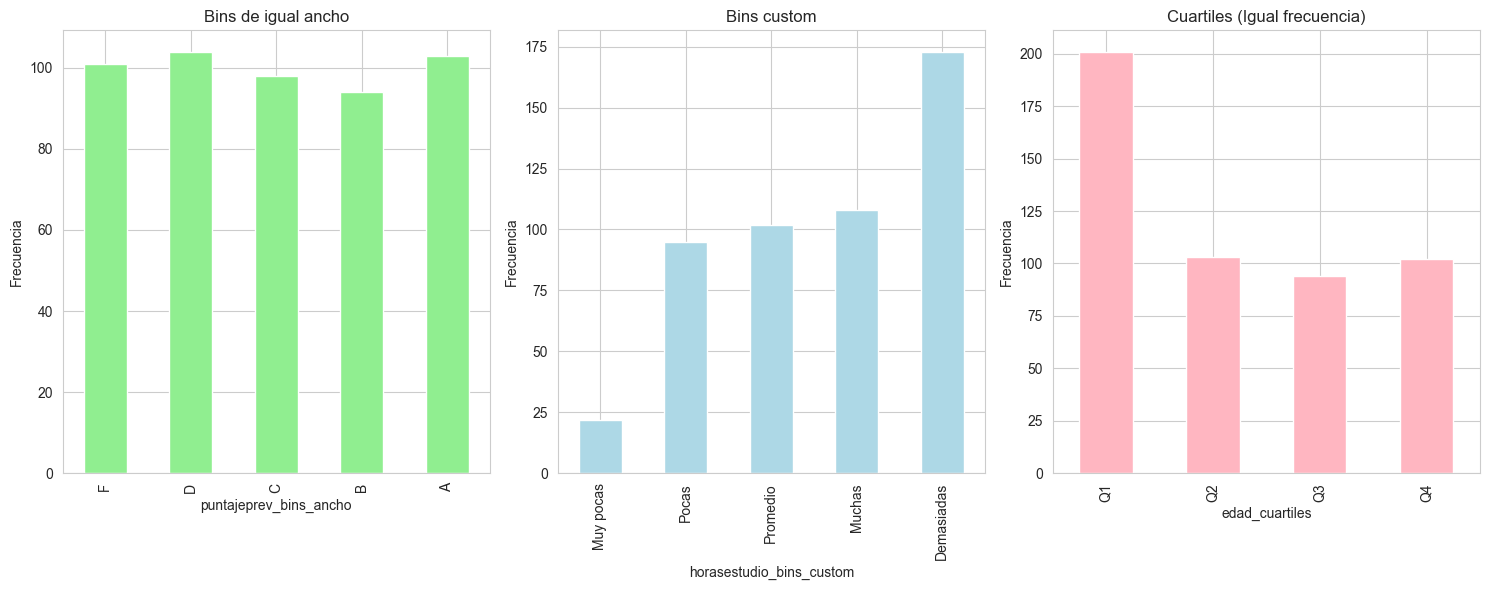

In [147]:
#Visualizamos binning
fig, axes = plt.subplots(1, 3, figsize=(15,6))

df['puntajeprev_bins_ancho'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightgreen')
axes[0].set_title('Bins de igual ancho')
axes[0].set_ylabel('Frecuencia')

df['horasestudio_bins_custom'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('Bins custom')
axes[1].set_ylabel('Frecuencia')

df['edad_cuartiles'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='lightpink')
axes[2].set_title('Cuartiles (Igual frecuencia)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show

Se crearon tres separaciones de bins con estrategias distintas sobre 'edad', 'horas de estudio semanales' y 'puntaje previo'.
- En el primer caso, se discretiza por el mismo ancho en todos los bins.
- En el segundo caso, se eligen valores 2, 7, 12 y 20 que son los valores mas contemplados en cuanto a estudio semanal.
- En el tercer caso, se divide en cuartiles, los cuales tienen aprox la misma cantidad en cada bin.

---

## Paso 6: Integracion de datos

Dada la falta de una segunda tabla para la cual realizar un join, decidimos saltarnos el paso y pasar directamente al acceso a APIs

---

## Paso 7: Acceso a APIs

Se utiliza la api publica OpenWeather para practicar.

In [148]:
API_Key = "3ec9983b3ad5672f09a525a946adb360"
ciudades = ["Paris","London","Stockholm","Tokyo","Bahia Blanca","Coronel Pringles","Punta Alta","Tres Arroyos","Tel aviv","Japon"]
datos = []
Url = "https://api.openweathermap.org/data/2.5/weather"

import requests
import pandas as pd


for ciudad in ciudades:
    params = {
        "q": ciudad,
        "appid": API_Key,
        "units": "metric"
    }
    
    response = requests.get(Url, params=params)
    
    
    if response.status_code == 200:
        data = response.json()
        fila = {
            "ciudad":data["name"],
            "temperatura":data["main"]["temp"],
            }
        datos.append(fila)
        
    else:
        print(f"Error con {i}", data)

df_temp = pd.DataFrame(datos)

print(df_temp)

             ciudad  temperatura
0             Paris        20.52
1            London        16.37
2         Stockholm         7.99
3             Tokyo        20.06
4      Bahía Blanca        15.29
5  Coronel Pringles        18.88
6        Punta Alta        15.43
7      Tres Arroyos        16.86
8          Tel Aviv        20.05
9             Japan        20.18


In [149]:
datos = []

for ciudad in ciudades:
    params = {
        'q' : ciudad,
        'appid' : API_Key,
        'units' : 'metric'
    }

    response2 = requests.get(Url, params=params)

    if response2.status_code == 200:
        data = response2.json()
        fila = {
            "ciudad":data["name"],
            "humedad":data["main"]["humidity"],
            "viento":data["wind"]["speed"],
            }
        datos.append(fila)
        
    else:
        print(f"Error con {i}", data)

df_humedvient = pd.DataFrame(datos)

print(df_humedvient)

             ciudad  humedad  viento
0             Paris       42    6.69
1            London       40    7.20
2         Stockholm       33    0.89
3             Tokyo       83    8.75
4      Bahía Blanca       55    5.66
5  Coronel Pringles       42    3.58
6        Punta Alta       55    5.66
7      Tres Arroyos       41    4.38
8          Tel Aviv       71    3.09
9             Japan       82    8.75


In [150]:
datos = []

for ciudad in ciudades:
    params = {
        'q' : ciudad,
        'appid' : API_Key,
        'units' : 'metric'
    }

    response3 = requests.get(Url, params=params)

    if response3.status_code == 200:
        data = response3.json()
        fila = {
            "ciudad":data["name"],
            "pais":data['sys']['country']
            }
        datos.append(fila)
        
    else:
        print(f"Error con {i}", data)

df_pais = pd.DataFrame(datos)

print(df_pais)

             ciudad pais
0             Paris   FR
1            London   GB
2         Stockholm   SE
3             Tokyo   JP
4      Bahía Blanca   AR
5  Coronel Pringles   AR
6        Punta Alta   AR
7      Tres Arroyos   AR
8          Tel Aviv   IL
9             Japan   JP


In [151]:
#Hacemos los joins de todos los dataframes, por medio de la columna ciudad

df_medio = pd.merge(df_temp, df_humedvient, on='ciudad')

print('Paso intermedio de el merge:')
print(df_medio)

df_total = pd.merge(df_medio, df_pais, on='ciudad')

print('\nEl join total queda:')
print(df_total)


Paso intermedio de el merge:
             ciudad  temperatura  humedad  viento
0             Paris        20.52       42    6.69
1            London        16.37       40    7.20
2         Stockholm         7.99       33    0.89
3             Tokyo        20.06       83    8.75
4      Bahía Blanca        15.29       55    5.66
5  Coronel Pringles        18.88       42    3.58
6        Punta Alta        15.43       55    5.66
7      Tres Arroyos        16.86       41    4.38
8          Tel Aviv        20.05       71    3.09
9             Japan        20.18       82    8.75

El join total queda:
             ciudad  temperatura  humedad  viento pais
0             Paris        20.52       42    6.69   FR
1            London        16.37       40    7.20   GB
2         Stockholm         7.99       33    0.89   SE
3             Tokyo        20.06       83    8.75   JP
4      Bahía Blanca        15.29       55    5.66   AR
5  Coronel Pringles        18.88       42    3.58   AR
6        Punta

Se eligieron 10 ciudades (las cuales fueron elegidas arbitrariamente, pero podrian ponerse otras) de las cuales:
- Se extrajeron sus nombres junto con la temperatura de lo cual se saco un dataframe.
- Se extrajeron nuevamente sus nombres esta vez junto con la humedad y la velocidad del viento (en m/s) de cada una, con lo que se creo otro dataframe.
- Por ultimo se extrajeron sus nombres pero en esa ocasion acompañados de el pais a que pertenecen cada una. Se realizo un Join de todos los dataframes con el fin de practicar joins, y resultando en un dataframe mas completo con datos importantes de cada una.

---

## Web Scraping

Usamos la pagina Books to scrape una pagina de venta de libros, pensada para scrapearse.

In [152]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url,headers=headers)

soup = BeautifulSoup(response.content, 'html.parser')

books = soup.find_all('article',class_='product_pod')

data = []

for book in books:
    titulo = book.h3.a["title"]
    
    precio = book.find("p", class_="price_color").text
    
    rating = book.find("p", class_="star-rating")["class"][1]
    
    data.append({
        "titulo": titulo,
        "precio": precio,
        "rating": rating
    })

df = pd.DataFrame(data)

print(df.head(15))


                                               titulo  precio rating
0                                A Light in the Attic  £51.77  Three
1                                  Tipping the Velvet  £53.74    One
2                                          Soumission  £50.10    One
3                                       Sharp Objects  £47.82   Four
4               Sapiens: A Brief History of Humankind  £54.23   Five
5                                     The Requiem Red  £22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  £33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  £17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  £22.60   Four
9                                     The Black Maria  £52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99    Two
11                              Shakespeare's Sonnets  £20.66   Four
12                                        Set Me Free  £17.46   Five
13  Scott Pilgrim's Precious Littl

---

## Paso 8: Tidy data

Usaremos el dataset creado en el punto anterior para trabajarlo con tidy data

In [153]:
#Hacemos una copia de las 10 primeras filas
df_wide = df.head(15).copy()

#Pivotamos
df_pivot = df_wide.pivot(index='titulo', columns='rating', values='precio')

df_pivot = df_pivot.fillna(0).reset_index()

print("Nuestro nuevo dataset en formato wide (respecto al rating) queda:\n")
print(df_pivot)



Nuestro nuevo dataset en formato wide (respecto al rating) queda:

rating                                             titulo    Five    Four  \
0                                    A Light in the Attic       0       0   
1                               Rip it Up and Start Again  £35.02       0   
2                   Sapiens: A Brief History of Humankind  £54.23       0   
3       Scott Pilgrim's Precious Little Life (Scott Pi...  £52.29       0   
4                                             Set Me Free  £17.46       0   
5                                   Shakespeare's Sonnets       0  £20.66   
6                                           Sharp Objects       0  £47.82   
7                                              Soumission       0       0   
8          Starving Hearts (Triangular Trade Trilogy, #1)       0       0   
9                                         The Black Maria       0       0   
10      The Boys in the Boat: Nine Americans and Their...       0  £22.60   
11      T

Lo que hicimos arriba fue cambiar de formato a Wide, por medio de pivot, lo que haremos a continuacion sera pasarlo de Wide a Long.


*Nota: Lo que se hizo con el fillna(0), es debido a que al pivotear en los libros que no posean el rating al cual la columna hace referencia los rellena con un NaN, por lo tanto lo mejor para seguirlo trabajando despues es reemplazarlos, aunque eso nos genere ruido a posteriori.*

In [154]:
#Melteamos
df_long = pd.melt(
    df_pivot,
    id_vars='titulo', 
    var_name='rating', 
    value_name='precio'
)
print("Dataset Long previo a corregir:")
print(df_long.head())

#Hay filas que no nos sirven resultante de haber hecho fillna(0), asi que nos las quitaremos de encima
df_long = df_long[df_long['precio'] != 0]
df_long = df_long.reset_index()
 
print("\nDataset Long ya corregido:")
print(df_long)

Dataset Long previo a corregir:
                                              titulo rating  precio
0                               A Light in the Attic   Five       0
1                          Rip it Up and Start Again   Five  £35.02
2              Sapiens: A Brief History of Humankind   Five  £54.23
3  Scott Pilgrim's Precious Little Life (Scott Pi...   Five  £52.29
4                                        Set Me Free   Five  £17.46

Dataset Long ya corregido:
    index                                             titulo rating  precio
0       1                          Rip it Up and Start Again   Five  £35.02
1       2              Sapiens: A Brief History of Humankind   Five  £54.23
2       3  Scott Pilgrim's Precious Little Life (Scott Pi...   Five  £52.29
3       4                                        Set Me Free   Five  £17.46
4      20                              Shakespeare's Sonnets   Four  £20.66
5      21                                      Sharp Objects   Four  £47.82


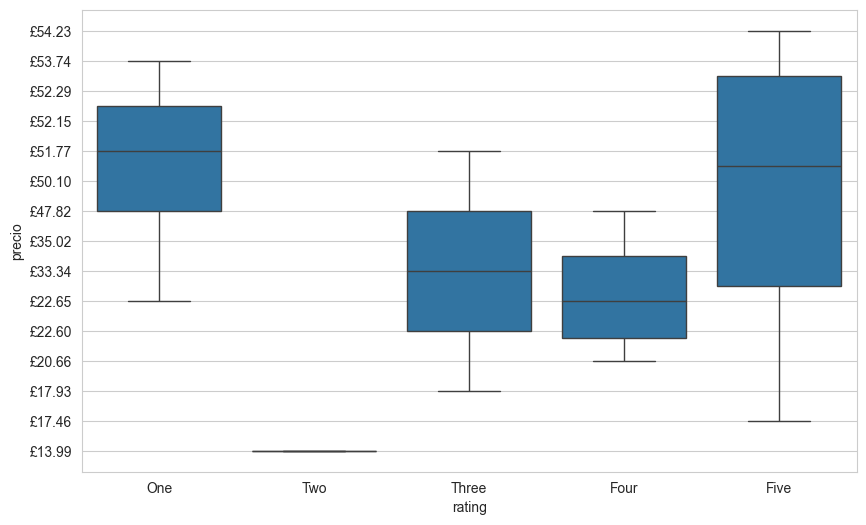

In [155]:
#Visualizamos: Usamos Long que es mejor para graficos

#Ordenamos a df_long de forma decresciente para que graficamente se vea mas lindo
df_sorted = df_long.sort_values('precio',ascending=False)

orden = ["One", "Two", "Three", "Four", "Five"]

sns.boxplot(data = df_sorted, x='rating', y='precio',order=orden)
plt.show()



Resumen: A partir del dataset original creamos un dataset en formato wide por medio de pivot, y posteriormente, se revirtio a formato long por medio de melt.

---